# LungScan AI — Improved Model Notebook

Perbaikan dari baseline model:
- **Augmentasi lebih kuat** (rotation ±25°, brightness, shear, shift)
- **ImageDataGenerator** langsung dari folder lokal (tidak perlu download Kaggle)
- **Full fine-tuning** — semua layer dibuka di tahap 2 (bukan hanya 30 terakhir)
- **Learning rate scheduling** lebih agresif
- **Class weights** dihitung otomatis dari distribusi dataset
- **Lebih banyak epoch** — 15 (head) + 20 (fine-tune)

Dataset: `chest-ctscan-images/` (lokal)
Kelas: adenocarcinoma, large_cell_carcinoma, squamous_cell_carcinoma, normal

In [6]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

# ── Paths ──────────────────────────────────────────────────────────────────
# Ubah DATA_DIR ke path dataset Anda
DATA_DIR   = r'C:\Users\trija\Documents\LungDetection\chest-ctscan-images'
EXPORT_DIR = r'C:\Users\trija\Documents\LungDetection'

# ── Hyperparameters ────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
NUM_CLASSES = 4
SEED        = 42

CLASSES = ['adenocarcinoma', 'large_cell_carcinoma', 'normal', 'squamous_cell_carcinoma']
# Catatan: ImageDataGenerator menggunakan urutan alfabetis folder
# Kita akan override class_indices setelah fit

tf.random.set_seed(SEED)
np.random.seed(SEED)
print('Setup selesai.')

TensorFlow: 2.20.0
GPU: []
Setup selesai.


## 1. Data Generators dengan Augmentasi Kuat

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Training generator: augmentasi kuat ────────────────────────────────────
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,          # putar ±25 derajat
    width_shift_range=0.15,     # geser horizontal ±15%
    height_shift_range=0.15,    # geser vertikal ±15%
    horizontal_flip=True,
    vertical_flip=True,         # CT scan valid diflip vertikal
    zoom_range=0.20,            # zoom in/out ±20%
    shear_range=0.10,           # geser sudut ±10%
    brightness_range=[0.70, 1.30],  # kecerahan ±30%
    fill_mode='nearest'
)

# ── Validation & Test generator: hanya preprocessing ───────────────────────
eval_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ── Flow dari folder ───────────────────────────────────────────────────────
train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    seed=SEED,
    shuffle=True
)

valid_gen = eval_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'valid'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

test_gen = eval_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

print('Train class indices:', train_gen.class_indices)
print('Valid class indices:', valid_gen.class_indices)
print('Test  class indices:', test_gen.class_indices)
print(f'Train: {train_gen.n} | Valid: {valid_gen.n} | Test: {test_gen.n}')

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Train class indices: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}
Valid class indices: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}
Test  class indices: {'adenocarcinoma': 0, 'large.cell.carcinoma': 1, 'normal': 2, 'squamous.cell.carcinoma': 3}
Train: 613 | Valid: 72 | Test: 315


## 2. Class Weights (counter imbalance)

In [8]:
# Hitung class weights dari distribusi training
y_train = train_gen.classes
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight = {int(c): float(w) for c, w in enumerate(class_weights_arr)}
print('Class weights:', class_weight)

# Tampilkan distribusi kelas
idx_to_label = {v: k for k, v in train_gen.class_indices.items()}
unique, counts = np.unique(y_train, return_counts=True)
for cls_idx, cnt in zip(unique, counts):
    print(f'  [{cls_idx}] {idx_to_label[cls_idx]}: {cnt} gambar (weight={class_weight[cls_idx]:.3f})')

Class weights: {0: 0.7858974358974359, 1: 1.3326086956521739, 2: 1.035472972972973, 3: 0.9887096774193549}
  [0] adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 195 gambar (weight=0.786)
  [1] large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 115 gambar (weight=1.333)
  [2] normal: 148 gambar (weight=1.035)
  [3] squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 155 gambar (weight=0.989)


## 3. Arsitektur Model — EfficientNetB0

Perbaikan dari baseline:
- `GlobalAveragePooling2D` → `Dense(256, relu)` → `BatchNormalization` → `Dropout(0.4)` → output
- Head lebih dalam untuk feature extraction yang lebih baik

In [9]:
def build_model(num_classes=4, img_size=(224, 224), trainable_base=False):
    base = keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=img_size + (3,)
    )
    base.trainable = trainable_base

    inputs  = keras.Input(shape=img_size + (3,), name='ct_image')
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D(name='gap')(x)
    x       = layers.Dense(256, activation='relu', name='fc1')(x)
    x       = layers.BatchNormalization(name='bn1')(x)
    x       = layers.Dropout(0.4, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='class_probability')(x)

    return keras.Model(inputs, outputs, name='lungscan_improved')

model = build_model(trainable_base=False)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "lungscan_improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ct_image (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probability (Dense)       │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,559 (16.71 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

## 4. Training Tahap 1 — Head Only (base frozen)

Latih hanya head baru selama 15 epoch, LR=1e-3

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage1 = [
    keras.callbacks.ModelCheckpoint(
        'best_improved_lungscan.keras',
        monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=6, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1
    ),
]

history_head = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks_stage1
)

print('Stage 1 selesai.')

Epoch 1/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4514 - loss: 1.6668
Epoch 1: val_accuracy improved from None to 0.52778, saving model to best_improved_lungscan.keras

Epoch 1: finished saving model to best_improved_lungscan.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.5090 - loss: 1.3974 - val_accuracy: 0.5278 - val_loss: 1.2214 - learning_rate: 0.0010
Epoch 2/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5807 - loss: 0.9123
Epoch 2: val_accuracy improved from 0.52778 to 0.61111, saving model to best_improved_lungscan.keras

Epoch 2: finished saving model to best_improved_lungscan.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.6150 - loss: 0.8859 - val_accuracy: 0.6111 - val_loss: 0.8478 - learning_rate: 0.0010
Epoch 3/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6458 - loss: 0.8309
Epoch 3: val_accuracy did not improve from 0.61111
39/39 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6639 - loss: 0.7935 - val_accuracy: 0.5972

## 5. Training Tahap 2 — Full Fine-Tuning

Buka SEMUA layer EfficientNetB0 (berbeda dari baseline yang hanya buka 30 layer terakhir).
LR sangat kecil (1e-5) untuk menghindari catastrophic forgetting.

In [11]:
# Buka SEMUA layer untuk fine-tuning
for layer in model.layers:
    layer.trainable = True

# Kompilasi ulang dengan LR sangat kecil
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage2 = [
    keras.callbacks.ModelCheckpoint(
        'best_improved_lungscan.keras',
        monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1
    ),
]

history_fine = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks_stage2
)

print('Stage 2 selesai.')

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4084 - loss: 1.8075
Epoch 1: val_accuracy improved from None to 0.66667, saving model to best_improved_lungscan.keras

Epoch 1: finished saving model to best_improved_lungscan.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 218s 4s/step - accuracy: 0.3964 - loss: 1.7891 - val_accuracy: 0.6667 - val_loss: 0.7470 - learning_rate: 1.0000e-05
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4655 - loss: 1.6443
Epoch 2: val_accuracy did not improve from 0.66667
39/39 ━━━━━━━━━━━━━━━━━━━━ 168s 4s/step - accuracy: 0.4698 - loss: 1.5326 - val_accuracy: 0.6389 - val_loss: 0.7917 - learning_rate: 1.0000e-05
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5047 - loss: 1.3224
Epoch 3: val_accuracy did not improve from 0.66667
39/39 ━━━━━━━━━━━━━━━━━━━━ 167s 4s/step - accuracy: 0.5073 - loss: 1.3519 - val_accuracy: 0.5556 - val_loss: 1.0256 - learning_rate: 1.0000e-05
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accu

## 6. Plot Training History

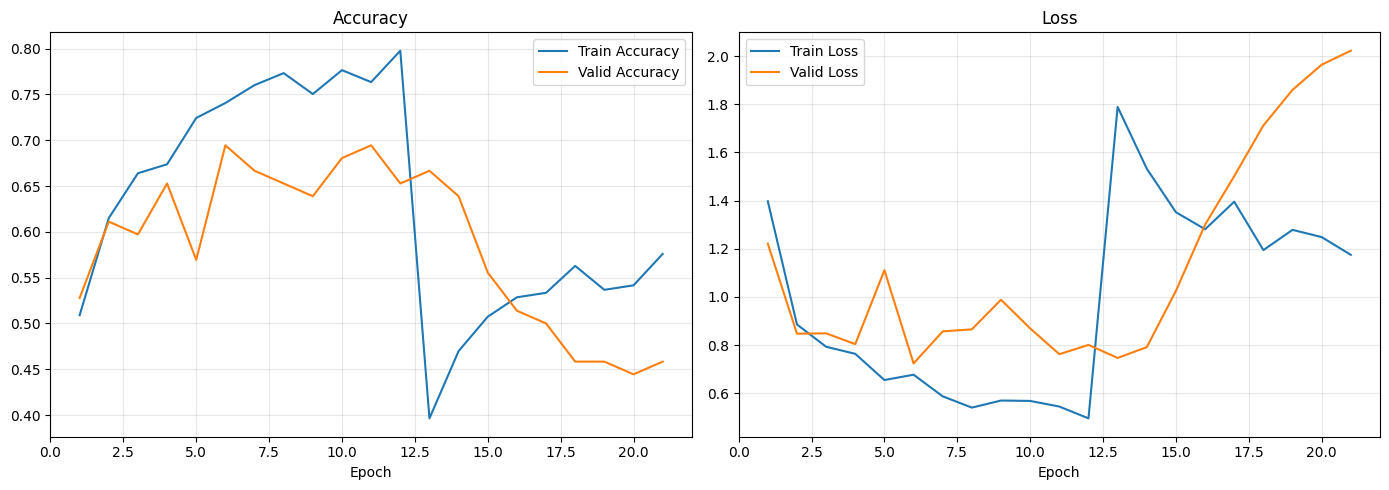

In [12]:
def plot_history(histories, labels=None):
    acc, val_acc, loss, val_loss = [], [], [], []
    for h in histories:
        acc     += h.history.get('accuracy', [])
        val_acc += h.history.get('val_accuracy', [])
        loss    += h.history.get('loss', [])
        val_loss+= h.history.get('val_loss', [])
    epochs = range(1, len(acc)+1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, acc, label='Train Accuracy')
    ax1.plot(epochs, val_acc, label='Valid Accuracy')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, loss, label='Train Loss')
    ax2.plot(epochs, val_loss, label='Valid Loss')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history([history_head, history_fine])

## 7. Evaluasi Test Set

20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 922ms/step - accuracy: 0.6159 - loss: 0.8458
Test Accuracy: 61.59%
Test Loss:     0.8458
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma     0.6306    0.5833    0.6061       120
   large.cell.carcinoma     0.3590    0.8235    0.5000        51
                 normal     1.0000    0.9815    0.9907        54
squamous.cell.carcinoma     0.8529    0.3222    0.4677        90

               accuracy                         0.6159       315
              macro avg     0.7106    0.6776    0.6411       315
           weighted avg     0.7135    0.6159    0.6153       315



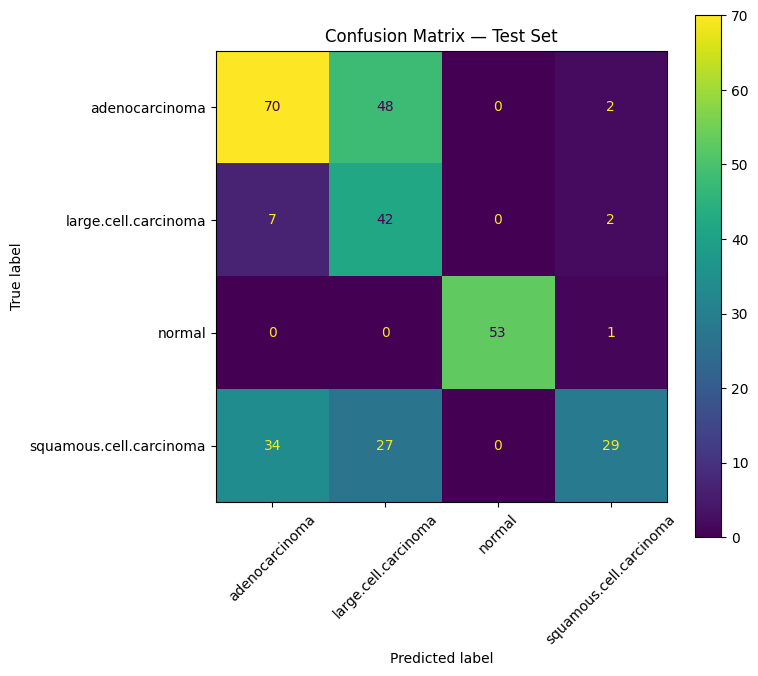

In [13]:
# Load model terbaik
best_model = keras.models.load_model('best_improved_lungscan.keras')

# Evaluasi pada test set
test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Loss:     {test_loss:.4f}')

# Prediksi untuk laporan per kelas
test_gen.reset()
y_true = test_gen.classes
y_pred = np.argmax(best_model.predict(test_gen, verbose=1), axis=1)

# Label names sesuai class_indices test generator
label_names = [k for k, v in sorted(test_gen.class_indices.items(), key=lambda x: x[1])]
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, xticks_rotation=45, values_format='d')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## 8. Simpan Model & Label Mapping

In [14]:
import shutil

# Simpan model ke folder LungDetection
model_path  = os.path.join(EXPORT_DIR, 'lungscan_ai_improved.keras')
weights_path= os.path.join(EXPORT_DIR, 'lungscan_ai_improved.weights.h5')

best_model.save(model_path)
best_model.save_weights(weights_path)

# Simpan label mapping
label_map = {
    'label_to_idx': train_gen.class_indices,
    'idx_to_label': {str(v): k for k, v in train_gen.class_indices.items()},
    'img_size': list(IMG_SIZE),
    'model_name': 'lungscan_ai_effnetb0_improved',
    'test_accuracy': round(float(test_acc * 100), 2)
}
with open(os.path.join(EXPORT_DIR, 'label_mapping_improved.json'), 'w') as f:
    json.dump(label_map, f, indent=2)

print('Model disimpan ke:', model_path)
print('Weights disimpan ke:', weights_path)
print('Label mapping:', label_map)

Model disimpan ke: /kaggle/Output/lungscan_ai_improved.keras
Weights disimpan ke: /kaggle/Output/lungscan_ai_improved.weights.h5
Label mapping: {'label_to_idx': {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}, 'idx_to_label': {'0': 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', '1': 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', '2': 'normal', '3': 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa'}, 'img_size': [224, 224], 'model_name': 'lungscan_ai_effnetb0_improved', 'test_accuracy': 61.59}


## 9. Langkah Selanjutnya

Setelah training selesai:
1. Cek confusion matrix — apakah semua kelas sudah seimbang?
2. Jika `large_cell_carcinoma` masih rendah → pertimbangkan data augmentation lebih agresif atau cari data tambahan
3. Jika hasil memuaskan → integrasikan `lungscan_ai_improved.keras` ke backend FastAPI
4. Update `model_accuracy` di backend response dengan nilai test accuracy yang nyata
5. **Disclaimer medis wajib** — model ini untuk screening awal, bukan diagnosis klinis definitif